# SINIM municipal capacity — exploration

**Dataset:** `data/sinim_municipal_capacity_2024-2025.csv` (345 comunas, SINIM 2024–2025).
**Question:** what does the municipal "who" layer let us say — and not say — about *financial feasibility* of climate actions?

Read alongside the README's interpretation warnings (nominal pesos; FCM dependency is over *own income* not total revenue; professionalization is generic escalafón not domain capacity; staff counts exclude honorarios; poverty is carried-forward CASEN; **population is not in this file**).

In [1]:
import pandas as pd, numpy as np, re, unicodedata
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110
Y="2025"
df=pd.read_csv("data/sinim_municipal_capacity_2024-2025.csv", dtype={"comuna_cut":str,"region_cut":str})
print("comunas:", len(df), "| regions:", df.region_cut.nunique())
df.head(3)

comunas: 345 | regions: 16


,comuna_cut,region_cut,comuna,fcm_dependency_pct_2025,fet_royalty_mineria_mclp_2025,ipp_percapita_mclp_2025,poverty_casen_pct_2025,presup_percapita_mclp_2025,professionalization_pct_2025,staff_contrata_directivo_2025,...,poverty_casen_pct_2024,presup_percapita_mclp_2024,professionalization_pct_2024,staff_contrata_directivo_2024,staff_contrata_profesional_2024,staff_directivo_total_2024,staff_planta_directivo_2024,staff_planta_profesional_2024,staff_profesional_total_2024,staff_total_2024
0,01101,01,Iquique,15.59,0.0,198.68,7.9,466.89,35.59,0.0,...,7.89,451.47,37.18,0.0,62.0,12.0,12.0,63.0,125.0,433.0
1,01107,01,Alto Hospicio,72.45,2026932.0,55.98,15.3,252.00,35.92,0.0,...,15.26,240.24,35.53,0.0,11.0,11.0,11.0,19.0,30.0,152.0
2,01401,01,Pozo Almonte,46.11,450711.0,358.77,15.3,1061.76,28.46,0.0,...,15.33,1196.12,29.37,0.0,9.0,8.0,8.0,7.0,16.0,143.0


## 1. Distributions — the fiscal story dominates

In [2]:
metrics=["fcm_dependency_pct","ipp_percapita_mclp","presup_percapita_mclp","professionalization_pct","staff_total","poverty_casen_pct"]
desc=df[[f"{m}_{Y}" for m in metrics]].describe(percentiles=[.1,.25,.5,.75,.9]).round(1).T
desc.index=[i.replace(f"_{Y}","") for i in desc.index]
desc

,count,mean,std,min,10%,25%,50%,75%,90%,max
fcm_dependency_pct,340.0,64.3,22.5,2.2,29.2,49.4,71.2,80.6,88.0,99.1
ipp_percapita_mclp,340.0,221.8,466.7,27.3,62.3,84.7,124.1,179.2,387.6,5369.4
presup_percapita_mclp,340.0,997.3,1763.4,199.2,302.1,397.5,537.7,885.5,1726.0,19819.1
professionalization_pct,327.0,40.8,9.8,0.0,29.6,34.6,40.0,46.2,53.0,76.7
staff_total,327.0,180.3,215.5,0.0,44.0,64.0,106.0,199.5,428.4,1904.0
poverty_casen_pct,345.0,9.0,4.4,0.9,3.6,6.0,8.6,11.6,14.8,24.3


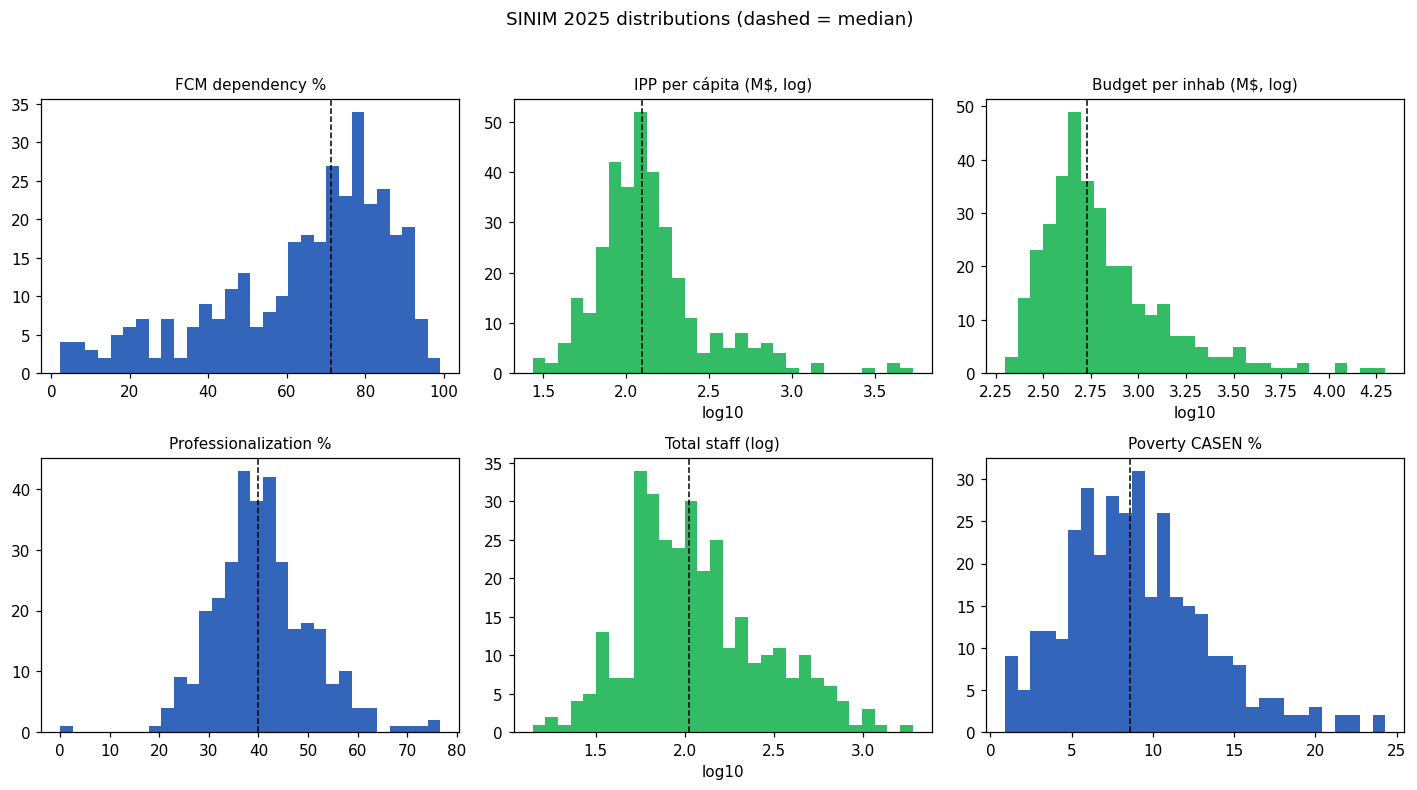

In [3]:
fig,ax=plt.subplots(2,3,figsize=(13,7))
specs=[("fcm_dependency_pct","FCM dependency %",False),
       ("ipp_percapita_mclp","IPP per cápita (M$, log)",True),
       ("presup_percapita_mclp","Budget per inhab (M$, log)",True),
       ("professionalization_pct","Professionalization %",False),
       ("staff_total","Total staff (log)",True),
       ("poverty_casen_pct","Poverty CASEN %",False)]
for a,(col,t,logx) in zip(ax.ravel(),specs):
    s=df[f"{col}_{Y}"].dropna()
    if logx: s=s[s>0]; a.hist(np.log10(s),bins=30,color="#3b6"); a.set_xlabel("log10")
    else: a.hist(s,bins=30,color="#36b")
    a.axvline((np.log10(s.median()) if logx else s.median()),color="k",ls="--",lw=1)
    a.set_title(t,fontsize=10)
fig.suptitle("SINIM 2025 distributions (dashed = median)",y=1.02); plt.tight_layout(); plt.show()

**Read:** FCM dependency has a **median of 71%** — the *typical* Chilean comuna funds roughly seven-tenths of its own income from the shared fund. Only the top quartile sits below ~49%. IPP-per-cápita and budget-per-inhabitant are extreme right-skewed (a few resource-rich micro-comunas). Professionalization is the tamest variable (mean ~41%, tight). So the headline: for **most** comunas, fiscal autonomy — the ability to co-finance — is structurally low.

## 2. How fiscally constrained is the median comuna?

In [4]:
dep=df[f"fcm_dependency_pct_{Y}"].dropna()
for thr in [50,70,80]:
    print(f"  comunas with FCM dependency > {thr}%: {(dep>thr).sum():3d}/{len(dep)} ({100*(dep>thr).mean():.0f}%)")
print(f"  median: {dep.median():.1f}%  | mean: {dep.mean():.1f}%")

  comunas with FCM dependency > 50%: 252/340 (74%)
  comunas with FCM dependency > 70%: 176/340 (52%)
  comunas with FCM dependency > 80%:  88/340 (26%)
  median: 71.2%  | mean: 64.3%


## 3. FETRO as an independent check on 'fiscally weak'

In [5]:
fet=df[f"fet_royalty_mineria_mclp_{Y}"].fillna(0)
pos=fet>0
print(f"comunas receiving FET royalty (2025): {pos.sum()}/{len(df)} ({100*pos.mean():.0f}%)")
print(f"  among recipients, FCM dependency >50%: {((pos)&(df[f'fcm_dependency_pct_{Y}']>50)).sum()}")
print(f"  mean FCM dependency  recipients vs non: {df[f'fcm_dependency_pct_{Y}'][pos].mean():.1f}% vs {df[f'fcm_dependency_pct_{Y}'][~pos].mean():.1f}%")
print(f"  mean IPP per cápita  recipients vs non: {df[f'ipp_percapita_mclp_{Y}'][pos].mean():.0f}  vs {df[f'ipp_percapita_mclp_{Y}'][~pos].mean():.0f}")

comunas receiving FET royalty (2025): 301/345 (87%)
  among recipients, FCM dependency >50%: 252
  mean FCM dependency  recipients vs non: 69.8% vs 26.8%
  mean IPP per cápita  recipients vs non: 212  vs 286


**Read:** the Chilean state itself flags **~87%** of comunas as fiscally weak (FET targets dependency >50% *or* bottom-80th-pct own income). Recipients average ~70% FCM dependency vs ~27% for non-recipients — so FETRO independently corroborates the fiscal-autonomy reading. The handful of low-dependency recipients qualify on the *low absolute own-income* leg, a nuance pure dependency-% misses.

## 4. Are fiscal autonomy and institutional capacity the same thing? (No)

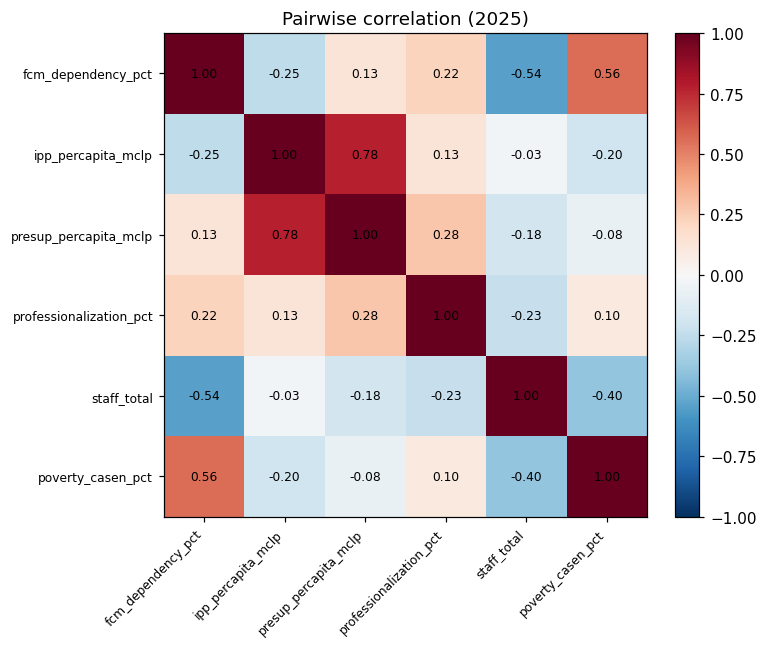

In [6]:
corr_cols=["fcm_dependency_pct","ipp_percapita_mclp","presup_percapita_mclp","professionalization_pct","staff_total","poverty_casen_pct"]
C=df[[f"{c}_{Y}" for c in corr_cols]].corr()
C.index=[i.replace(f"_{Y}","") for i in C.index]; C.columns=C.index
fig,ax=plt.subplots(figsize=(7,6))
im=ax.imshow(C,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns,rotation=45,ha="right",fontsize=8)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index,fontsize=8)
for i in range(len(C)):
    for j in range(len(C)): ax.text(j,i,f"{C.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
plt.colorbar(im,fraction=0.046); ax.set_title("Pairwise correlation (2025)"); plt.tight_layout(); plt.show()

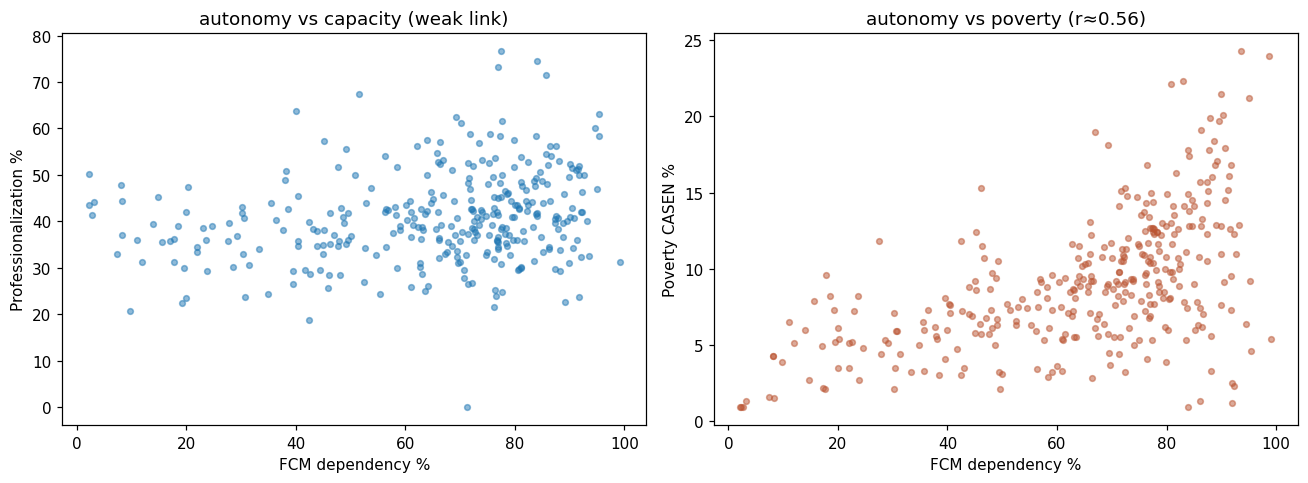

In [7]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(df[f"fcm_dependency_pct_{Y}"],df[f"professionalization_pct_{Y}"],s=14,alpha=.5)
ax[0].set_xlabel("FCM dependency %"); ax[0].set_ylabel("Professionalization %"); ax[0].set_title("autonomy vs capacity (weak link)")
ax[1].scatter(df[f"fcm_dependency_pct_{Y}"],df[f"poverty_casen_pct_{Y}"],s=14,alpha=.5,color="#b53")
ax[1].set_xlabel("FCM dependency %"); ax[1].set_ylabel("Poverty CASEN %"); ax[1].set_title("autonomy vs poverty (r≈0.56)")
plt.tight_layout(); plt.show()

**Read:** FCM dependency correlates with poverty (+0.56) and inversely with absolute staff (−0.54, a size effect), but only **weakly** with professionalization (+0.22). So *fiscal autonomy* and *institutional capacity* are related but **distinct axes** — a poor, dependent comuna can still run a reasonably professionalized (if small) team. That means the "who" layer needs **both** axes, not one composite — they answer different questions (can it pay? vs. can it execute?).

## 5. Outliers worth knowing

In [8]:
print("Top IPP per cápita (resource/mining micro-comunas):")
print(df.nlargest(5,f"ipp_percapita_mclp_{Y}")[["comuna",f"ipp_percapita_mclp_{Y}",f"fcm_dependency_pct_{Y}",f"fet_royalty_mineria_mclp_{Y}"]].to_string(index=False))
print("\nHighest FCM dependency (fiscally captured):")
print(df.nlargest(5,f"fcm_dependency_pct_{Y}")[["comuna",f"fcm_dependency_pct_{Y}",f"ipp_percapita_mclp_{Y}",f"professionalization_pct_{Y}",f"staff_total_{Y}"]].to_string(index=False))

Top IPP per cápita (resource/mining micro-comunas):
      comuna  ipp_percapita_mclp_2025  fcm_dependency_pct_2025  fet_royalty_mineria_mclp_2025
   Río Verde                  5369.44                    66.32                       276162.0
Sierra Gorda                  4131.13                    30.21                       285998.0
     Ollagüe                  3948.89                    70.22                       278267.0
    Zapallar                  2684.52                     8.22                            0.0
       Alhué                  1490.51                    17.83                       310204.0

Highest FCM dependency (fiscally captured):
        comuna  fcm_dependency_pct_2025  ipp_percapita_mclp_2025  professionalization_pct_2025  staff_total_2025
Isla De Pascua                    99.14                    27.32                         31.25              96.0
        Camiña                    98.75                    27.70                           NaN               NaN


**Read:** mining/resource comunas (Río Verde, Sierra Gorda, Ollagüe) have huge per-cápita own income — the FCM-only lens the Diversidad note warns about would misclassify them; IPP-per-cápita catches them. At the other end, near-totally-dependent comunas (Isla de Pascua, Camiña, Tortel ~95–99%) are exactly where capital-intensive actions are least self-financeable.

## 6. Revealed capacity — join to the projects pipeline

In [9]:
def norm(s):
    if pd.isna(s): return None
    s=unicodedata.normalize('NFKD',str(s)).encode('ascii','ignore').decode().upper().strip()
    return re.sub(r'\s+',' ',s)
proj=pd.read_csv("../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/projects_profiled.csv")
proj["key"]=proj["comuna"].map(norm); df["key"]=df["comuna"].map(norm)
n_proj=proj.groupby("key").size().rename("n_projects")
m=df.merge(n_proj,on="key",how="left"); m["n_projects"]=m["n_projects"].fillna(0)
print(f"SINIM comunas matched to >=1 project: {(m.n_projects>0).sum()}/{len(m)} ({100*(m.n_projects>0).mean():.0f}%)")
print(f"projects carrying a comuna value: {proj['comuna'].notna().sum()}/{len(proj)} ({100*proj['comuna'].notna().mean():.0f}%)")
for cm in ["staff_total","professionalization_pct","ipp_percapita_mclp","fcm_dependency_pct"]:
    print(f"  corr(n_projects, {cm}) = {m['n_projects'].corr(m[f'{cm}_{Y}']):.2f}")

SINIM comunas matched to >=1 project: 266/345 (77%)
projects carrying a comuna value: 1514/3144 (48%)
  corr(n_projects, staff_total) = 0.35
  corr(n_projects, professionalization_pct) = -0.12
  corr(n_projects, ipp_percapita_mclp) = -0.10
  corr(n_projects, fcm_dependency_pct) = -0.25


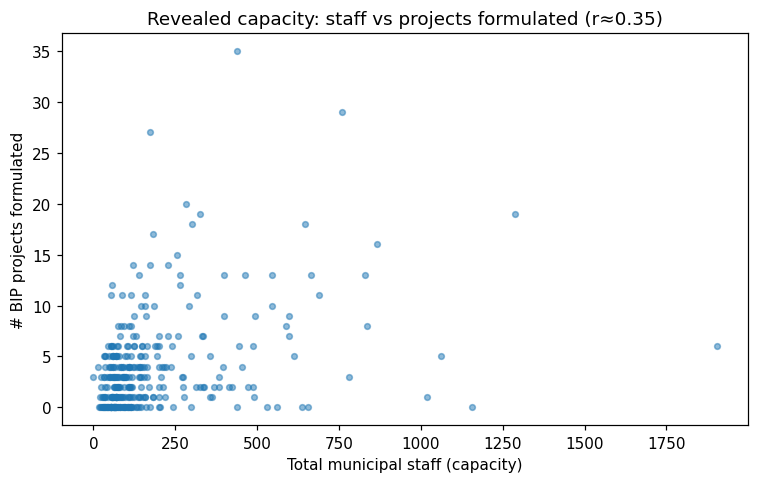

In [10]:
fig,ax=plt.subplots(figsize=(7,4.5))
ax.scatter(m[f"staff_total_{Y}"],m["n_projects"],s=14,alpha=.5)
ax.set_xlabel("Total municipal staff (capacity)"); ax.set_ylabel("# BIP projects formulated")
ax.set_title("Revealed capacity: staff vs projects formulated (r≈0.35)")
plt.tight_layout(); plt.show()

**Read:** larger-staffed comunas formulate more projects (r≈0.35) and more-dependent ones formulate slightly fewer (−0.25) — the *direction* the Diversidad note's "formulation-capacity bottleneck" predicts. But it's **weak and confounded by size**, and the projects' `comuna` field is only ~48% populated, so this is **suggestive, not proof**.

## 7. What we CAN and CANNOT say about financial feasibility

**CAN say (supported by this data):**
- The **actor side is fiscally constrained for most of Chile** — median FCM dependency ~71%, ~3 in 4 comunas above 50%. For capital-intensive actions, the *typical* comuna cannot self- or co-finance. This validates the Diversidad note's premise with numbers.
- We can **differentiate comunas** on two real, distinct axes — fiscal autonomy (can it pay / co-finance?) and institutional capacity (can it execute?) — and modulate the flat finance-coverage label into a city-specific readiness signal.
- The **FETRO flag independently corroborates** the fiscally-weak group (87% flagged; recipients ~70% vs ~27% dependency), and **IPP-per-cápita rescues the mining-comuna exception** the FCM-only view misreads.

**CANNOT say (out of scope for this dataset):**
- **Nothing about whether a specific action gets funded.** This is actor capacity/autonomy, not project *bankability*, *adequacy* (amount vs cost), *competitiveness* (award odds), or *capacity to apply* — the finance-inventory facets 3–5 remain unmeasured.
- **No SUBDERE bracket / size weighting yet** — population is not in the file (it's only embedded in per-cápita denominators). Add `cl-ine-censo`.
- **Not domain capacity** — professionalization ≠ climate/urban-planning skill or an environmental unit; staff counts exclude honorarios, so small-comuna capacity is understated and nulls ≠ zero.
- **Not a funding-outcome signal** — the projects join is weak, size-confounded, and half-missing on `comuna`; and there is no award/disbursement history here. Correlation here is not the causal driver of funding success.
- **No real trend** — nominal pesos and carried-forward poverty; treat as a 2025 snapshot.